In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB

In [5]:
df=pd.read_csv('/content/drive/MyDrive/DATASETS/customer_churn_data.csv')
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [6]:
df.tail()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,NaN,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes
999,1000,50,Male,1,56.67,Month-to-Month,NaN,56.67,No,Yes


In [7]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [8]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,297
TotalCharges,0
TechSupport,0
Churn,0


In [9]:
df['InternetService']=df['InternetService'].fillna(df['InternetService'].mode()[0])
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,Fiber Optic,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,Fiber Optic,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,Fiber Optic,4465.56,No,Yes


In [10]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,0
TotalCharges,0
TechSupport,0
Churn,0


In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
con=['Gender','ContractType','InternetService','TechSupport',	'Churn']
for c in con:
  df[c]=le.fit_transform(df[c])
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,1,4,88.35,0,1,353.40,1,1
1,2,43,1,0,36.67,0,1,0.00,1,1
2,3,51,0,2,63.79,0,1,127.58,0,1
3,4,60,0,8,102.34,1,0,818.72,1,1
4,5,42,1,32,69.01,0,1,2208.32,0,1
...,...,...,...,...,...,...,...,...,...,...
995,996,42,1,41,37.14,0,1,1522.74,1,1
996,997,62,1,9,80.93,0,1,728.37,0,1
997,998,51,0,15,111.72,0,1,1675.80,1,1
998,999,39,1,68,65.67,1,1,4465.56,0,1


In [12]:
x=df.drop(['Churn'],axis=1)
y=df['Churn']

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [17]:
nb_model = GaussianNB()
nb_model.fit(x_train, y_train)

GaussianNB()

In [19]:
y_pred = nb_model.predict(x_test)
print(y_pred)

[1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0
 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1
 1 0 0 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1
 0 1 0 1 1 1 1 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0 1 0 1 0 1 1 1 1 0 1 0 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 1 1 0 1 1
 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 0 0 0 0 1 1 1 1
 1 1 1 1]


In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.89


In [21]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.97      0.70        39
           1       1.00      0.88      0.93       261

    accuracy                           0.89       300
   macro avg       0.77      0.93      0.82       300
weighted avg       0.94      0.89      0.90       300



[[ 38   1]
 [ 32 229]]


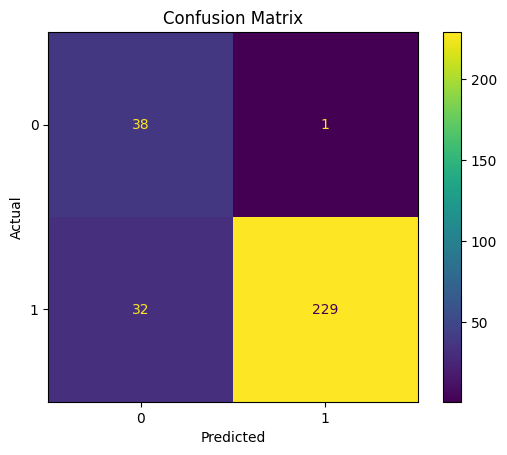

In [26]:
cm=confusion_matrix(y_test, y_pred)
print(cm)
c=ConfusionMatrixDisplay(cm)
c.plot()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()
